<table><tr><th><div style='padding:15px;color:#030aa7;font-size:240%;text-align:center;font-weight:bold;font-family:Georgia,serif'>Explorer les relations — Logs web</div></th></tr></table>
<table><tr><th><div style='padding:15px;color:#e50000;font-size:240%;text-align:center;font-style:italic;font-weight:bold;font-family:Georgia,serif'>Quelles mesures varient ensemble ?</div></th></tr></table>

<div style='text-align:center'><img src='https://raw.githubusercontent.com/rbizoi/dockerBigDataBI/refs/heads/master/images/bi/famille_3.png' width='1024'></div>
<div style='text-align:center'><img src='https://raw.githubusercontent.com/rbizoi/dockerBigDataBI/refs/heads/master/images/bi/famille_3_description.png' width='1024'></div>

<div style='padding:15px;color:#030aa7;font-family:Georgia,serif'>Atelier BI · Famille 04 · 6 graphiques × 3 bibliothèques</div>

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Introduction</div></b>

Le fichier couvre seulement le 22 janvier 2019, de 00:26 à 07:36 UTC environ. Les premières et dernières minutes sont incomplètes. Les mesures portent sur des requêtes, pas sur des personnes. Les adresses IP et URL brutes ne sont pas chargées.

**Objectif :** construire les six représentations de cette famille sur les données réelles, comparer les encodages et interpréter leurs limites. Les trois variantes utilisent exactement la même table préparée. Les constructions composites Seaborn sont signalées : cette bibliothèque ne propose pas tous les types nativement.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Sommaire</div></b>

1. Nuage de points
2. Bulles
3. Hexagones de densité
4. Matrice de corrélation
5. Matrice de nuages ou pairplot
6. Coordonnées parallèles

Exécution : ouvrir le dossier extrait, sélectionner un noyau Python avec les dépendances de `requirements.txt`, puis **Redémarrer le noyau et tout exécuter**. Les résultats sont déjà enregistrés. Adapter `config_donnees.json` si les fichiers changent de place.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Import des bibliothèques</div></b>

In [1]:
NOM_PROJET = '04_web'
from pathlib import Path
import os, json, warnings
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle, Polygon, Wedge
from matplotlib.collections import PatchCollection
from matplotlib.colors import Normalize
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from scipy.stats import gaussian_kde
import networkx as nx
import squarify

get_ipython().run_line_magic('matplotlib', 'inline')
SEED = 42
palette = ["#030aa7", "#e50000", "#d8863b", "#005f6a", "#6b7c85", "#751973",
           "#0485d1", "#ff7855", "#fbeeac", "#0cb577", "#95a3a6", "#c071fe"]
sns.set_theme(style='darkgrid', palette=palette, context='notebook', font_scale=1.05)
plt.rcParams.update({'figure.figsize': (11, 5), 'figure.dpi': 110})
pio.templates['bi_modele'] = pio.templates['plotly_white']
pio.templates['bi_modele'].layout.colorway = palette
pio.templates.default = 'bi_modele'
pio.renderers.default = 'plotly_mimetype'
px.defaults.color_discrete_sequence = palette
EXPORTER = False  # True : PNG statiques et HTML interactifs dans repertoire.images.
repertoireImages = Path('repertoire.images') / NOM_PROJET

def sauvegarderImage(nom, fig=None):
    fig = fig if fig is not None else plt.gcf()
    if EXPORTER:
        repertoireImages.mkdir(parents=True, exist_ok=True)
        fig.savefig(repertoireImages / (nom + '.png'), dpi=180, bbox_inches='tight')

def terminer(ax, titre, xlabel=None, ylabel=None):
    ax.set_title(titre, loc='left', fontweight='bold', pad=14)
    if xlabel is not None: ax.set_xlabel(xlabel)
    if ylabel is not None: ax.set_ylabel(ylabel)
    ax.figure.tight_layout()
    sauvegarderImage(ID_GRAPHIQUE + '_' + BIBLIOTHEQUE, ax.figure)
    plt.show()
    plt.close(ax.figure)

def montrer_plotly(fig, titre):
    fig.update_layout(title=titre, width=1000, height=520,
                      margin=dict(l=70, r=45, t=90, b=75),
                      font=dict(family='Arial', size=13))
    if EXPORTER:
        repertoireImages.mkdir(parents=True, exist_ok=True)
        fig.write_html(repertoireImages / (ID_GRAPHIQUE + '_plotly.html'), include_plotlyjs=True)
    fig.show()

def creer_axes(seaborn=False, **kwargs):
    # Matplotlib reste autonome ; Seaborn garde le style et la palette du modèle.
    plt.style.use('default')
    if seaborn: sns.set_theme(style='darkgrid', palette=palette, context='notebook')
    return plt.subplots(figsize=(11, 5), **kwargs)

print('Versions :', 'pandas', pd.__version__, 'seaborn', sns.__version__,
      'plotly', __import__('plotly').__version__, 'matplotlib', __import__('matplotlib').__version__)

Versions : pandas 2.3.3 seaborn 0.13.2 plotly 7.1.0 matplotlib 3.10.9


## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Outils du document</div></b>

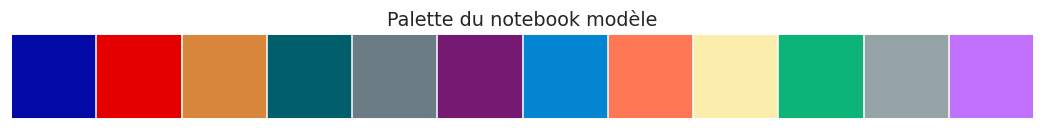

In [2]:
sns.palplot(sns.color_palette(palette))
plt.title('Palette du notebook modèle')
plt.show()
plt.close('all')

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Lecture des données</div></b>

<table><tr><th style="background:#053061;color:white">Colonne</th><th style="background:#053061;color:white">Description</th></tr><tr><td>datetime</td><td>Horodatage UTC</td></tr><tr><td>status / classe_http</td><td>Code HTTP et famille de code</td></tr><tr><td>bytes / taille_ko</td><td>Octets transférés et kilo-octets binaires (÷ 1024)</td></tr><tr><td>device_type / referer_type</td><td>Classe appareil et type de référent déjà présents dans le fichier</td></tr><tr><td>is_bot</td><td>Détection de robot fournie, non réestimée</td></tr><tr><td>geo_country_code / geo_latitude / geo_longitude</td><td>Géolocalisation fournie, indicative ; pas une position individuelle vérifiée</td></tr></table>

In [3]:
CHEMINS = {'meteo': '/opt/spark/data/meteo.gzip', 'web': '/opt/spark/data/Web.Server.Access10.gzip', 'ecommerce': '/opt/spark/notebooks/ecommerce'}
configuration = Path('config_donnees.json')
if configuration.exists():
    CHEMINS.update(json.loads(configuration.read_text(encoding='utf-8')))
for cle in CHEMINS:
    CHEMINS[cle] = os.environ.get('BI_' + cle.upper(), CHEMINS[cle])
assert Path(CHEMINS['web']).exists(), 'Vérifier config_donnees.json'

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Contrôle des données et préparation</div></b>

In [4]:
colonnes = ['datetime', 'method', 'status', 'bytes', 'device_type', 'referer_type',
            'is_bot', 'geo_country_code', 'geo_latitude', 'geo_longitude', 'url_parameter_count']
brut = pd.read_parquet(CHEMINS['web'], columns=colonnes)
donnees = brut.copy()
donnees['datetime'] = pd.to_datetime(donnees['datetime'], utc=True, errors='coerce')
valides = donnees['datetime'].notna() & donnees['status'].between(100, 599) & donnees['bytes'].ge(0)
print(f'Lignes source : {len(brut):,} ; hors critères techniques : {(~valides).sum():,}')
donnees = donnees.loc[valides].copy()
for col in ['method', 'device_type', 'referer_type', 'geo_country_code']:
    donnees[col] = donnees[col].fillna('Inconnu')
donnees['classe_http'] = (donnees['status'] // 100).astype(str) + 'xx'
donnees['erreur'] = donnees['status'].ge(400)
donnees['minute'] = donnees['datetime'].dt.floor('min')
donnees['taille_ko'] = donnees['bytes'] / 1024
print('Périmètre UTC :', donnees['datetime'].min(), '→', donnees['datetime'].max())
print('Les requêtes ne sont pas des visiteurs ; les octets ne sont pas des temps de réponse.')
assert len(donnees) > 0
display(donnees.describe(include='all').T)

Lignes source : 499,997 ; hors critères techniques : 0
Périmètre UTC : 2019-01-22 00:26:14+00:00 → 2019-01-22 07:36:14+00:00
Les requêtes ne sont pas des visiteurs ; les octets ne sont pas des temps de réponse.


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
datetime,499997,NaN,NaN,NaN,2019-01-22 05:36:38.271808768+00:00,2019-01-22 00:26:14+00:00,2019-01-22 04:49:36+00:00,2019-01-22 05:56:38+00:00,2019-01-22 06:49:12+00:00,2019-01-22 07:36:14+00:00,NaN
method,499997,5,GET,490457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,499997.0,<NA>,<NA>,<NA>,207.91811,200.0,200.0,200.0,200.0,504.0,34.678443
bytes,499997.0,<NA>,<NA>,<NA>,12771.083188,0.0,1955.0,3876.0,13126.0,1249490.0,26326.91015
device_type,499997,5,PC,321284,NaN,NaN,NaN,NaN,NaN,NaN,NaN
referer_type,499997,5,Internal,369107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_bot,499997,2,False,436678,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geo_country_code,499997,76,IR,337870,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geo_latitude,496377.0,NaN,NaN,NaN,37.61343,-38.0365,35.698,35.698,37.751,66.0899,6.617004
geo_longitude,496377.0,NaN,NaN,NaN,21.131996,-123.1981,11.0783,51.4115,51.4115,174.7675,56.968638


# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Statistiques descriptives et analyse de données</div></b>

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>1 — Nuage de points</div></b>

Explorer volume de requêtes et taille moyenne des réponses par minute complète. Variables : deux mesures Q ; un point est une minute. Une relation agrégée ne prouve pas une causalité.

In [5]:
a=donnees.groupby('minute').agg(requetes=('status','size'),taille_moyenne=('taille_ko','mean'),taux_erreur=('erreur','mean'),part_bots=('is_bot','mean')).reset_index()
# Exclure seulement les minutes aux deux bornes, potentiellement incomplètes.
a=a.loc[a.minute.gt(donnees.datetime.min().floor('min')) & a.minute.lt(donnees.datetime.max().floor('min'))].copy()
a[['taux_erreur','part_bots']]*=100
a['requetes']=a['requetes'].astype('int64')  # Compatibilité de la légende Seaborn avec les types pandas.
display(a.describe().T)

,count,mean,std,min,25%,50%,75%,max
requetes,429.0,1163.820513,975.594146,133.0,270.0,839.0,2041.0,4126.0
taille_moyenne,429.0,15.695038,4.930034,9.202047,11.563082,13.701771,19.820426,29.132288
taux_erreur,429.0,1.898826,1.777055,0.0,0.830368,1.345794,2.222222,14.859438
part_bots,429.0,27.153498,20.631484,1.733269,8.681961,18.131868,43.067847,87.919463


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

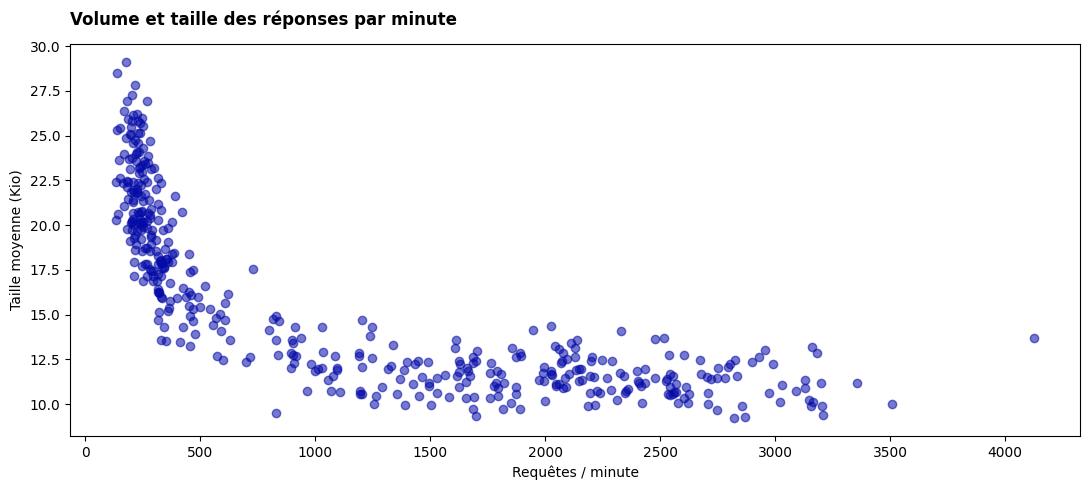

In [6]:
ID_GRAPHIQUE = '04_01'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
ax.scatter(a.requetes,a.taille_moyenne,alpha=.55,color=palette[0])
terminer(ax,'Volume et taille des réponses par minute','Requêtes / minute','Taille moyenne (Kio)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn</div></b>

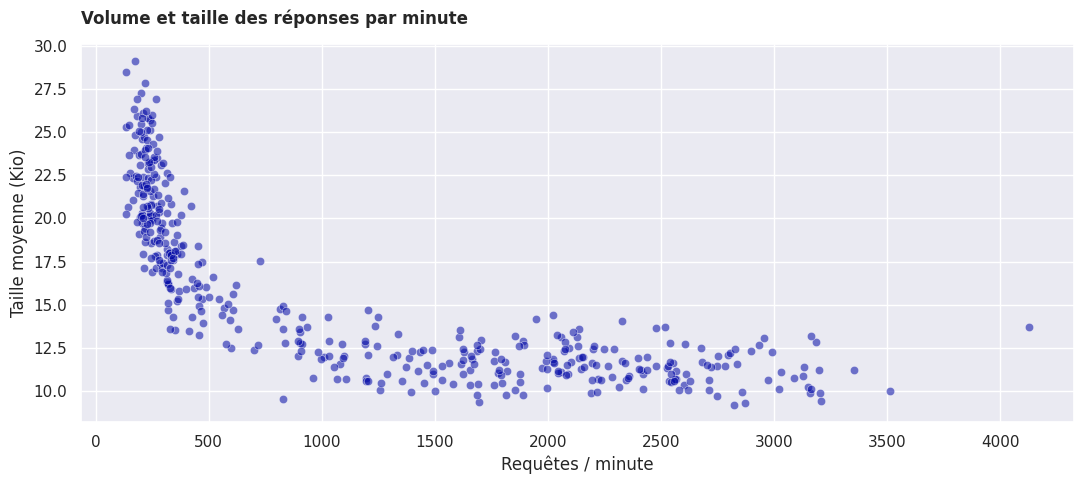

In [7]:
ID_GRAPHIQUE = '04_01'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
sns.scatterplot(data=a,x='requetes',y='taille_moyenne',alpha=.55,color=palette[0],ax=ax)
terminer(ax,'Volume et taille des réponses par minute','Requêtes / minute','Taille moyenne (Kio)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

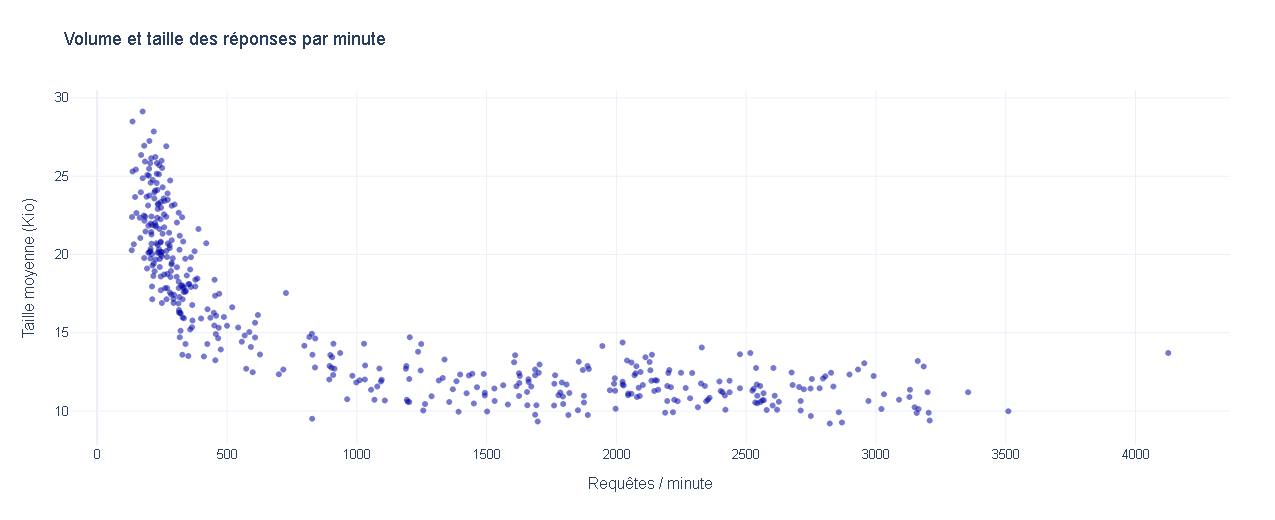

In [8]:
ID_GRAPHIQUE = '04_01'
BIBLIOTHEQUE = 'plotly'
fig=px.scatter(a,x='requetes',y='taille_moyenne',hover_data=['minute'],opacity=.55,labels={'requetes':'Requêtes / minute','taille_moyenne':'Taille moyenne (Kio)'})
montrer_plotly(fig,'Volume et taille des réponses par minute')

**À lire dans les trois variantes :** Explorer volume de requêtes et taille moyenne des réponses par minute complète. Variables : deux mesures Q ; un point est une minute. Une relation agrégée ne prouve pas une causalité.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>2 — Bulles</div></b>

Ajouter le nombre de requêtes comme aire de bulle au couple part de robots / taux d’erreur. Variables : 3Q ; une bulle = une minute complète. La taille représente une aire, jamais un rayon.

In [9]:
a=donnees.groupby('minute').agg(requetes=('status','size'),taille_moyenne=('taille_ko','mean'),taux_erreur=('erreur','mean'),part_bots=('is_bot','mean')).reset_index()
# Exclure seulement les minutes aux deux bornes, potentiellement incomplètes.
a=a.loc[a.minute.gt(donnees.datetime.min().floor('min')) & a.minute.lt(donnees.datetime.max().floor('min'))].copy()
a[['taux_erreur','part_bots']]*=100
a['requetes']=a['requetes'].astype('int64')  # Compatibilité de la légende Seaborn avec les types pandas.
display(a.describe().T)

,count,mean,std,min,25%,50%,75%,max
requetes,429.0,1163.820513,975.594146,133.0,270.0,839.0,2041.0,4126.0
taille_moyenne,429.0,15.695038,4.930034,9.202047,11.563082,13.701771,19.820426,29.132288
taux_erreur,429.0,1.898826,1.777055,0.0,0.830368,1.345794,2.222222,14.859438
part_bots,429.0,27.153498,20.631484,1.733269,8.681961,18.131868,43.067847,87.919463


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

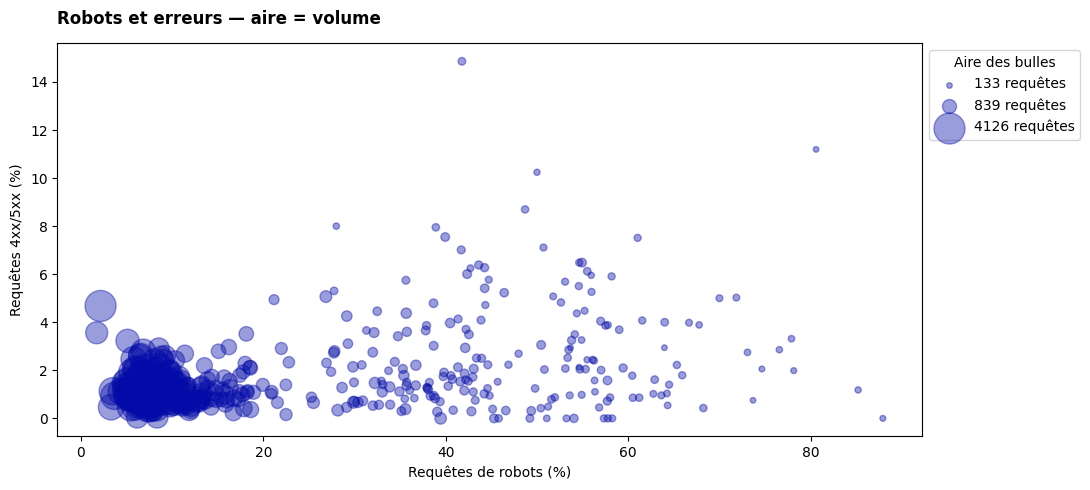

In [10]:
ID_GRAPHIQUE = '04_02'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
sizes=500*a.requetes/a.requetes.max();ax.scatter(a.part_bots,a.taux_erreur,s=sizes,alpha=.4,color=palette[0])
for n in [int(a.requetes.min()),int(a.requetes.median()),int(a.requetes.max())]:ax.scatter([],[],s=500*n/a.requetes.max(),label=f'{n} requêtes',color=palette[0],alpha=.4)
ax.legend(title='Aire des bulles',loc='upper left',bbox_to_anchor=(1,1))
terminer(ax,'Robots et erreurs — aire = volume','Requêtes de robots (%)','Requêtes 4xx/5xx (%)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn</div></b>

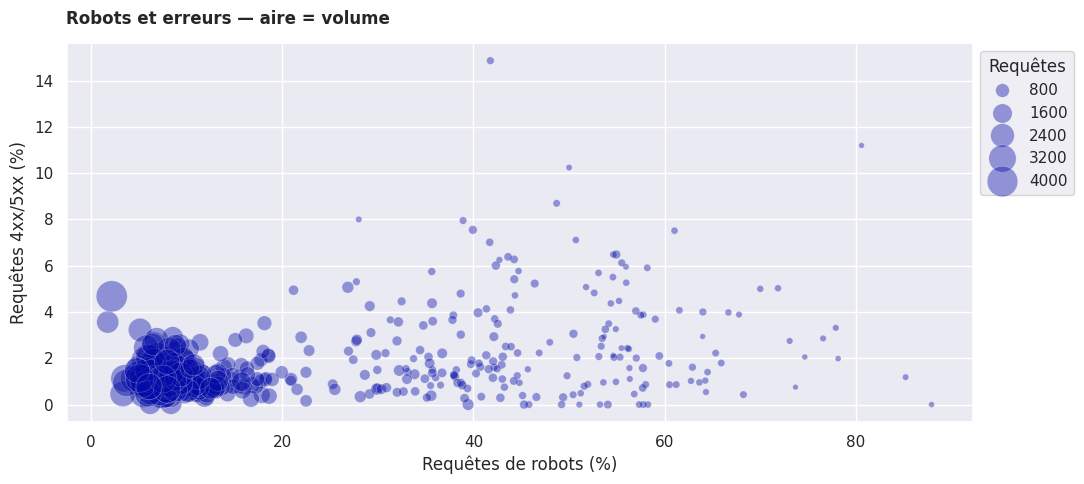

In [11]:
ID_GRAPHIQUE = '04_02'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
sns.scatterplot(data=a,x='part_bots',y='taux_erreur',size='requetes',sizes=(500*a.requetes.min()/a.requetes.max(),500),alpha=.4,color=palette[0],ax=ax)
ax.legend(title='Requêtes',loc='upper left',bbox_to_anchor=(1,1))
terminer(ax,'Robots et erreurs — aire = volume','Requêtes de robots (%)','Requêtes 4xx/5xx (%)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

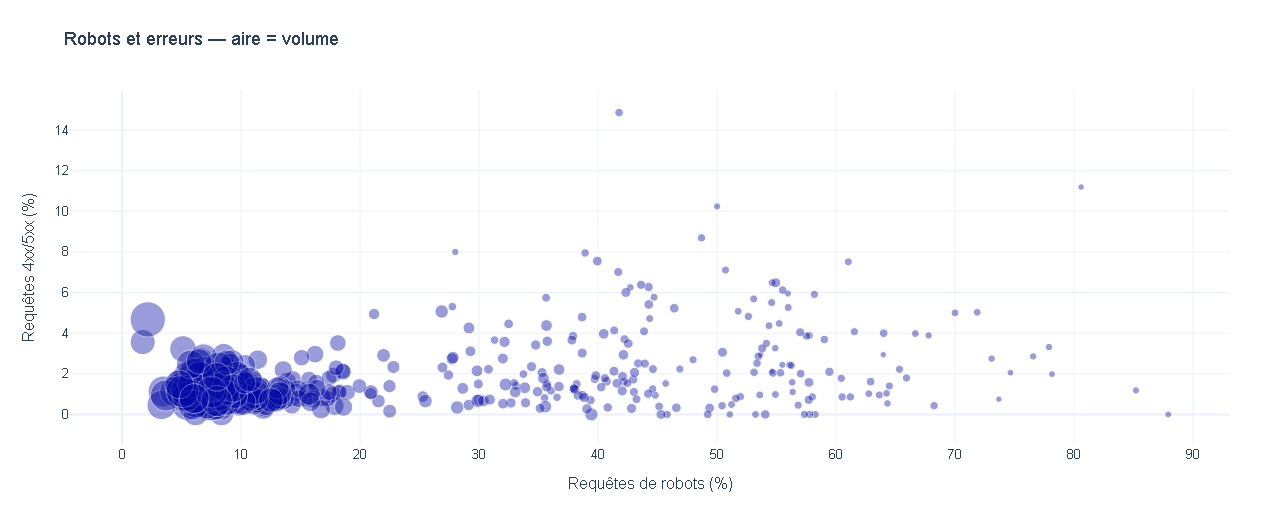

In [12]:
ID_GRAPHIQUE = '04_02'
BIBLIOTHEQUE = 'plotly'
fig=px.scatter(a,x='part_bots',y='taux_erreur',size='requetes',size_max=25,opacity=.4,hover_data=['minute'],labels={'part_bots':'Requêtes de robots (%)','taux_erreur':'Requêtes 4xx/5xx (%)','requetes':'Requêtes'})
montrer_plotly(fig,'Robots et erreurs — aire = volume')

**À lire dans les trois variantes :** Ajouter le nombre de requêtes comme aire de bulle au couple part de robots / taux d’erreur. Variables : 3Q ; une bulle = une minute complète. La taille représente une aire, jamais un rayon.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>3 — Hexagones de densité</div></b>

Agrégation hexagonale des requêtes : nombre de paramètres d’URL et log10(1 + taille en octets). Variables : 2Q ; la couleur représente log10(1 + effectif) de chaque cellule. Les mêmes polygones sont utilisés dans les trois variantes.

In [13]:
d=donnees[['url_parameter_count','bytes']].dropna().copy()
d['log_octets']=np.log10(1+d['bytes'])
# Matplotlib calcule le pavage et les effectifs ; ses polygones sont réutilisés.
tmp,ax_tmp=plt.subplots()
hb=ax_tmp.hexbin(d.url_parameter_count,d.log_octets,gridsize=22,mincnt=1)
centres=hb.get_offsets().copy();comptes=np.asarray(hb.get_array()).copy();forme=hb.get_paths()[0].vertices.copy()
plt.close(tmp)
polygones=[forme+centre for centre in centres]
intensite=np.log10(1+comptes);normalisation=Normalize(float(intensite.min()),float(intensite.max()))
cmap=plt.get_cmap('Blues')
assert int(comptes.sum())==len(d)
print('Requêtes agrégées :',len(d),'; hexagones non vides :',len(comptes))

Requêtes agrégées : 499997 ; hexagones non vides : 108


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

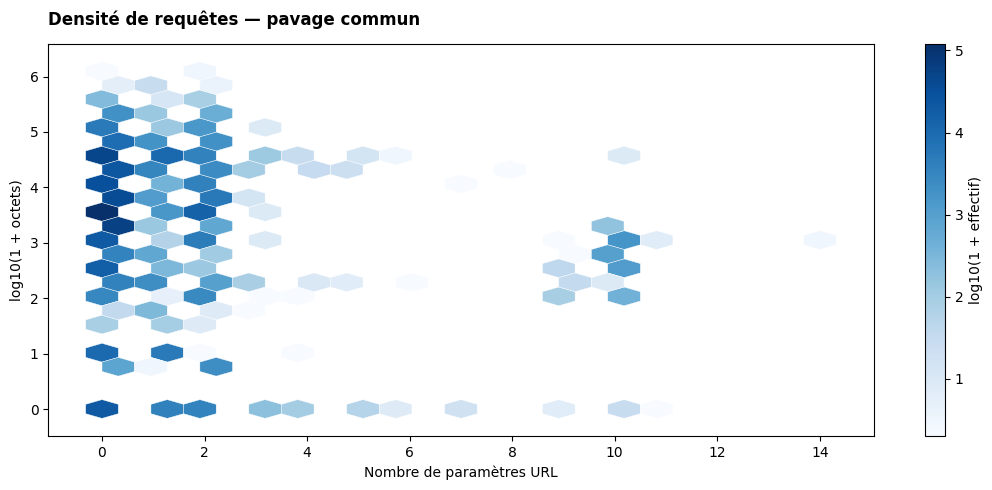

In [14]:
ID_GRAPHIQUE = '04_03'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
pc=PatchCollection([Polygon(p) for p in polygones],cmap=cmap,norm=normalisation,edgecolor='white',linewidth=.3);pc.set_array(intensite);ax.add_collection(pc);ax.autoscale_view();fig.colorbar(pc,ax=ax,label='log10(1 + effectif)')
terminer(ax,'Densité de requêtes — pavage commun','Nombre de paramètres URL','log10(1 + octets)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

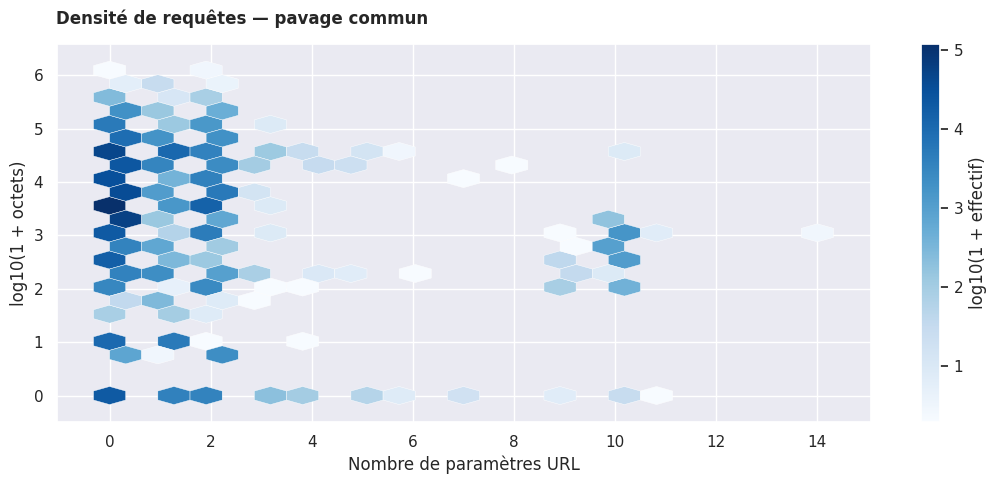

In [15]:
ID_GRAPHIQUE = '04_03'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
cmap_sns=sns.color_palette('Blues',as_cmap=True)
pc=PatchCollection([Polygon(p) for p in polygones],cmap=cmap_sns,norm=normalisation,edgecolor='white',linewidth=.3);pc.set_array(intensite);ax.add_collection(pc);ax.autoscale_view();fig.colorbar(pc,ax=ax,label='log10(1 + effectif)')
terminer(ax,'Densité de requêtes — pavage commun','Nombre de paramètres URL','log10(1 + octets)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

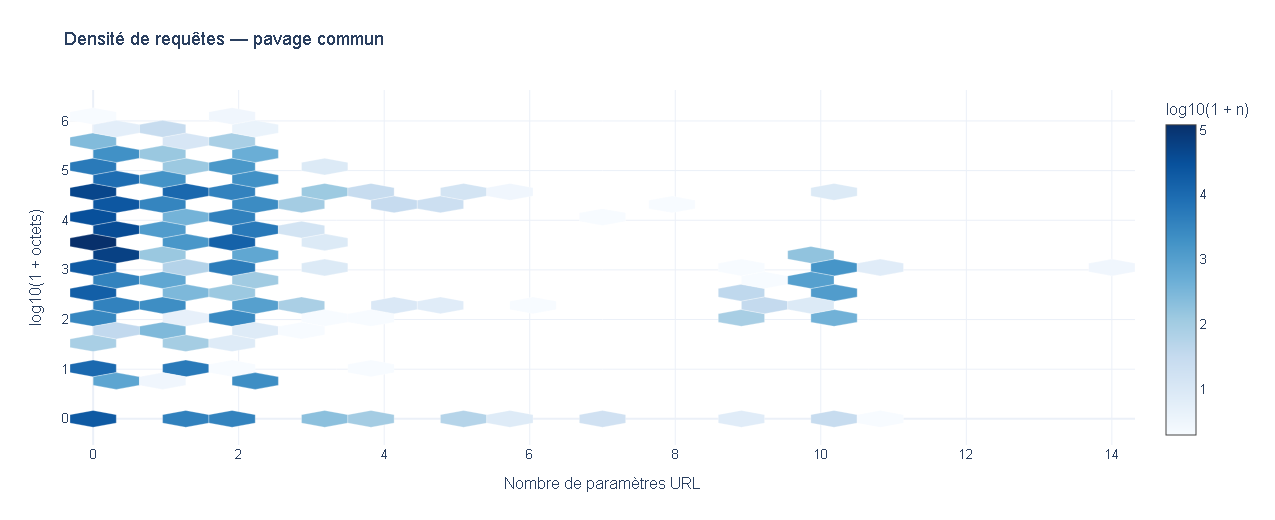

In [16]:
ID_GRAPHIQUE = '04_03'
BIBLIOTHEQUE = 'plotly'
fig=go.Figure()
for p,v,n in zip(polygones,intensite,comptes):
    rgb=cmap(normalisation(v))[:3];couleur='rgb('+','.join(str(round(255*t)) for t in rgb)+')'
    fig.add_trace(go.Scatter(x=p[:,0],y=p[:,1],fill='toself',fillcolor=couleur,mode='lines',line=dict(color='white',width=.3),showlegend=False,hovertemplate=f'{int(n)} requêtes<extra></extra>'))
fig.add_trace(go.Scatter(x=[None,None],y=[None,None],mode='markers',marker=dict(color=[float(intensite.min()),float(intensite.max())],colorscale='Blues',showscale=True,colorbar_title='log10(1 + n)'),showlegend=False))
fig.update_layout(xaxis_title='Nombre de paramètres URL',yaxis_title='log10(1 + octets)')
montrer_plotly(fig,'Densité de requêtes — pavage commun')

**À lire dans les trois variantes :** Agrégation hexagonale des requêtes : nombre de paramètres d’URL et log10(1 + taille en octets). Variables : 2Q ; la couleur représente log10(1 + effectif) de chaque cellule. Les mêmes polygones sont utilisés dans les trois variantes.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>4 — Matrice de corrélation</div></b>

Comparer les corrélations de Pearson des indicateurs par minute. Variables : quatre mesures Q ; coefficients entre −1 et +1. La dépendance temporelle et les variables omises empêchent toute conclusion causale.

In [17]:
a=donnees.groupby('minute').agg(requetes=('status','size'),taille_moyenne=('taille_ko','mean'),taux_erreur=('erreur','mean'),part_bots=('is_bot','mean')).reset_index()
# Exclure seulement les minutes aux deux bornes, potentiellement incomplètes.
a=a.loc[a.minute.gt(donnees.datetime.min().floor('min')) & a.minute.lt(donnees.datetime.max().floor('min'))].copy()
a[['taux_erreur','part_bots']]*=100
a['requetes']=a['requetes'].astype('int64')  # Compatibilité de la légende Seaborn avec les types pandas.
display(a.describe().T)

variables=['requetes','taille_moyenne','taux_erreur','part_bots']
corr=a[variables].corr(method='pearson')
display(corr)

,count,mean,std,min,25%,50%,75%,max
requetes,429.0,1163.820513,975.594146,133.0,270.0,839.0,2041.0,4126.0
taille_moyenne,429.0,15.695038,4.930034,9.202047,11.563082,13.701771,19.820426,29.132288
taux_erreur,429.0,1.898826,1.777055,0.0,0.830368,1.345794,2.222222,14.859438
part_bots,429.0,27.153498,20.631484,1.733269,8.681961,18.131868,43.067847,87.919463


,requetes,taille_moyenne,taux_erreur,part_bots
requetes,1.000000,-0.783150,-0.328219,-0.840089
taille_moyenne,-0.783150,1.000000,0.389438,0.898476
taux_erreur,-0.328219,0.389438,1.000000,0.361863
part_bots,-0.840089,0.898476,0.361863,1.000000


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

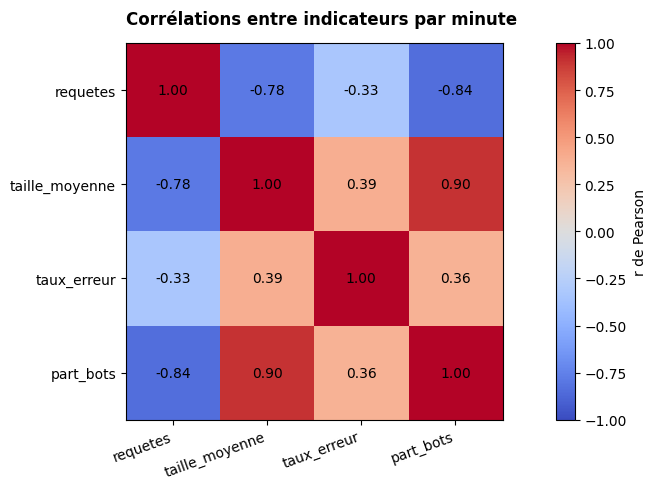

In [18]:
ID_GRAPHIQUE = '04_04'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
im=ax.imshow(corr,vmin=-1,vmax=1,cmap='coolwarm');ax.set_xticks(range(4),variables,rotation=20,ha='right');ax.set_yticks(range(4),variables)
for i in range(4):
    for j in range(4):ax.text(j,i,f'{corr.iloc[i,j]:.2f}',ha='center',va='center',color='black')
fig.colorbar(im,ax=ax,label='r de Pearson')
terminer(ax,'Corrélations entre indicateurs par minute')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn</div></b>

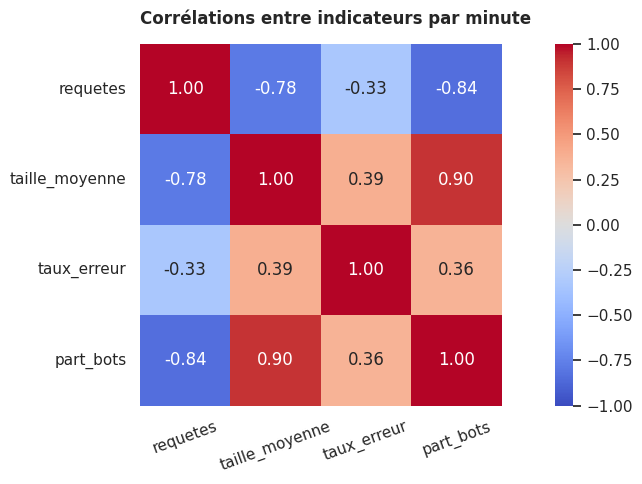

In [19]:
ID_GRAPHIQUE = '04_04'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
sns.heatmap(corr,vmin=-1,vmax=1,center=0,cmap='coolwarm',annot=True,fmt='.2f',square=True,ax=ax);ax.tick_params(axis='x',rotation=20)
terminer(ax,'Corrélations entre indicateurs par minute')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [20]:
ID_GRAPHIQUE = '04_04'
BIBLIOTHEQUE = 'plotly'
fig=px.imshow(corr,zmin=-1,zmax=1,color_continuous_scale='RdBu_r',text_auto='.2f')
montrer_plotly(fig,'Corrélations entre indicateurs par minute')

**À lire dans les trois variantes :** Comparer les corrélations de Pearson des indicateurs par minute. Variables : quatre mesures Q ; coefficients entre −1 et +1. La dépendance temporelle et les variables omises empêchent toute conclusion causale.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>5 — Matrice de nuages</div></b>

Observer quatre indicateurs deux à deux sur toutes les minutes complètes. Variables : 4Q ; diagonale = histogramme à 20 classes, hors diagonale = points. Le nombre de panneaux croît au carré.

In [21]:
a=donnees.groupby('minute').agg(requetes=('status','size'),taille_moyenne=('taille_ko','mean'),taux_erreur=('erreur','mean'),part_bots=('is_bot','mean')).reset_index()
# Exclure seulement les minutes aux deux bornes, potentiellement incomplètes.
a=a.loc[a.minute.gt(donnees.datetime.min().floor('min')) & a.minute.lt(donnees.datetime.max().floor('min'))].copy()
a[['taux_erreur','part_bots']]*=100
a['requetes']=a['requetes'].astype('int64')  # Compatibilité de la légende Seaborn avec les types pandas.
display(a.describe().T)

variables=['requetes','taille_moyenne','taux_erreur','part_bots']
display(a[variables].head())

,count,mean,std,min,25%,50%,75%,max
requetes,429.0,1163.820513,975.594146,133.0,270.0,839.0,2041.0,4126.0
taille_moyenne,429.0,15.695038,4.930034,9.202047,11.563082,13.701771,19.820426,29.132288
taux_erreur,429.0,1.898826,1.777055,0.0,0.830368,1.345794,2.222222,14.859438
part_bots,429.0,27.153498,20.631484,1.733269,8.681961,18.131868,43.067847,87.919463


,requetes,taille_moyenne,taux_erreur,part_bots
1,287,19.446793,1.74216,39.721254
2,331,20.829795,3.021148,38.670695
3,425,16.494455,4.941176,21.176471
4,246,20.162153,3.658537,31.300813
5,245,18.584702,5.306122,27.755102


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

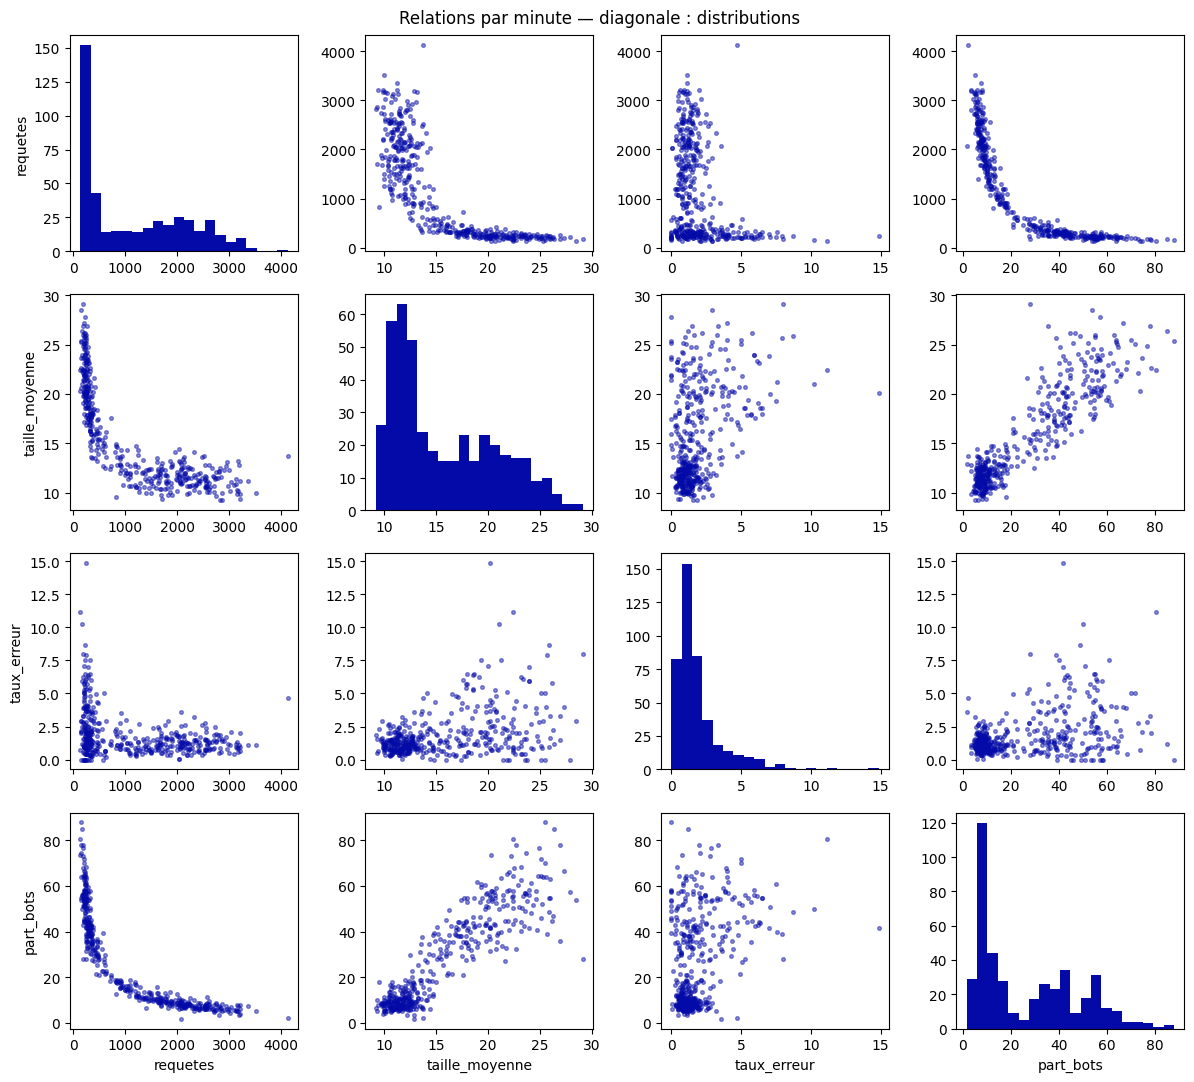

In [22]:
ID_GRAPHIQUE = '04_05'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,axes=plt.subplots(4,4,figsize=(12,11))
for i,y in enumerate(variables):
    for j,x in enumerate(variables):
        ax=axes[i,j]
        if i==j:ax.hist(a[x],bins=20,color=palette[0])
        else:ax.scatter(a[x],a[y],s=7,alpha=.45,color=palette[0])
        if i==3:ax.set_xlabel(x)
        if j==0:ax.set_ylabel(y)
fig.suptitle('Relations par minute — diagonale : distributions');fig.tight_layout();sauvegarderImage(ID_GRAPHIQUE+'_matplotlib',fig);plt.show();plt.close(fig)

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn</div></b>

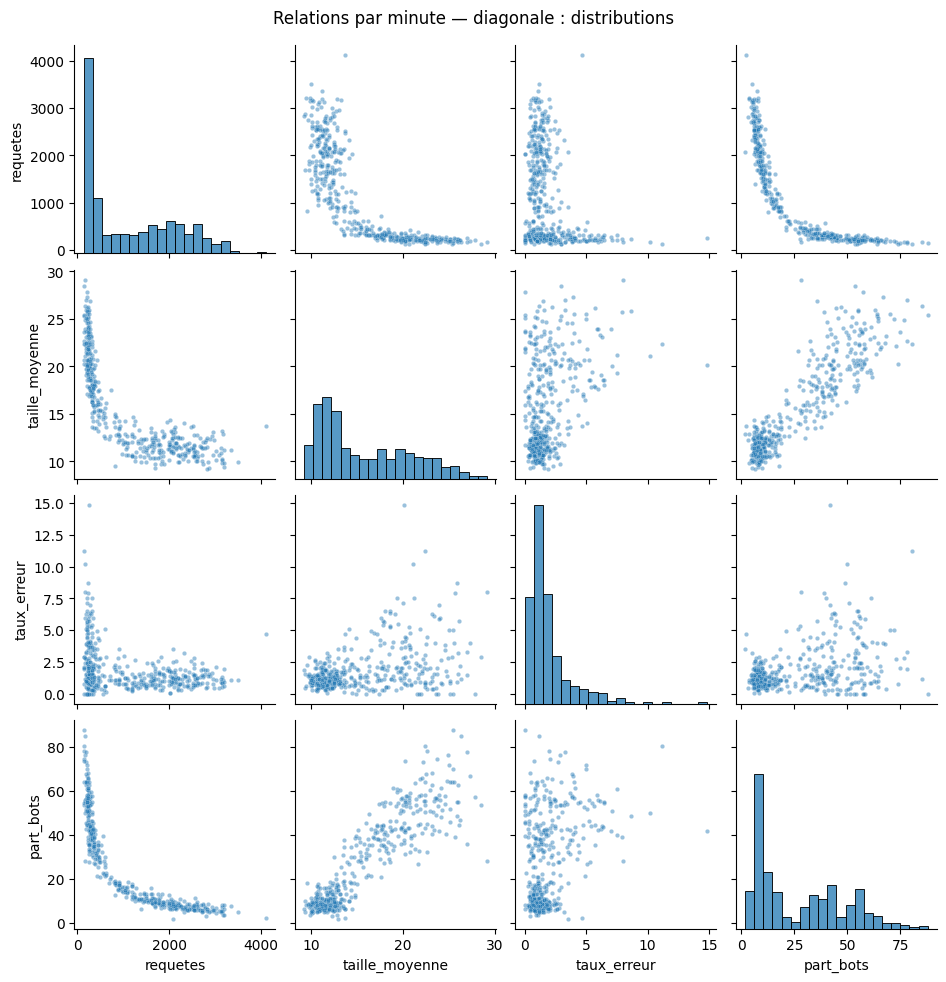

In [23]:
ID_GRAPHIQUE = '04_05'
BIBLIOTHEQUE = 'seaborn'
g=sns.pairplot(a[variables],diag_kind='hist',plot_kws={'s':10,'alpha':.45},diag_kws={'bins':20},height=2.4)
g.figure.suptitle('Relations par minute — diagonale : distributions',y=1.02);sauvegarderImage(ID_GRAPHIQUE+'_seaborn',g.figure);plt.show();plt.close(g.figure)

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [24]:
ID_GRAPHIQUE = '04_05'
BIBLIOTHEQUE = 'plotly'
fig=make_subplots(rows=4,cols=4)
for i,y in enumerate(variables):
    for j,x in enumerate(variables):
        if i==j:
            counts,edges=np.histogram(a[x],bins=20);trace=go.Bar(x=(edges[:-1]+edges[1:])/2,y=counts,width=np.diff(edges),showlegend=False)
        else:trace=go.Scatter(x=a[x],y=a[y],mode='markers',marker=dict(size=4,opacity=.45),showlegend=False)
        fig.add_trace(trace,row=i+1,col=j+1)
        if i==3:fig.update_xaxes(title_text=x,row=i+1,col=j+1)
        if j==0:fig.update_yaxes(title_text=y,row=i+1,col=j+1)
fig.update_layout(width=1000,height=950,title='Relations par minute — diagonale : distributions');fig.show()

**À lire dans les trois variantes :** Observer quatre indicateurs deux à deux sur toutes les minutes complètes. Variables : 4Q ; diagonale = histogramme à 20 classes, hors diagonale = points. Le nombre de panneaux croît au carré.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>6 — Coordonnées parallèles</div></b>

Comparer 80 profils de minutes, échantillonnés avec une graine fixe. Variables : 4Q. Min–max calculé sur toutes les minutes complètes ; les valeurs normalisées ne conservent pas les unités.

In [25]:
a=donnees.groupby('minute').agg(requetes=('status','size'),taille_moyenne=('taille_ko','mean'),taux_erreur=('erreur','mean'),part_bots=('is_bot','mean')).reset_index()
# Exclure seulement les minutes aux deux bornes, potentiellement incomplètes.
a=a.loc[a.minute.gt(donnees.datetime.min().floor('min')) & a.minute.lt(donnees.datetime.max().floor('min'))].copy()
a[['taux_erreur','part_bots']]*=100
a['requetes']=a['requetes'].astype('int64')  # Compatibilité de la légende Seaborn avec les types pandas.
display(a.describe().T)

variables=['requetes','taille_moyenne','taux_erreur','part_bots']
minimum=a[variables].min();amplitude=(a[variables].max()-minimum).replace(0,1)
normalise=(a[variables]-minimum)/amplitude
ech=normalise.sample(n=min(80,len(a)),random_state=SEED)
display(pd.DataFrame({'min':minimum,'max':a[variables].max()}))

,count,mean,std,min,25%,50%,75%,max
requetes,429.0,1163.820513,975.594146,133.0,270.0,839.0,2041.0,4126.0
taille_moyenne,429.0,15.695038,4.930034,9.202047,11.563082,13.701771,19.820426,29.132288
taux_erreur,429.0,1.898826,1.777055,0.0,0.830368,1.345794,2.222222,14.859438
part_bots,429.0,27.153498,20.631484,1.733269,8.681961,18.131868,43.067847,87.919463


,min,max
requetes,133.0,4126.0
taille_moyenne,9.202047,29.132288
taux_erreur,0.0,14.859438
part_bots,1.733269,87.919463


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

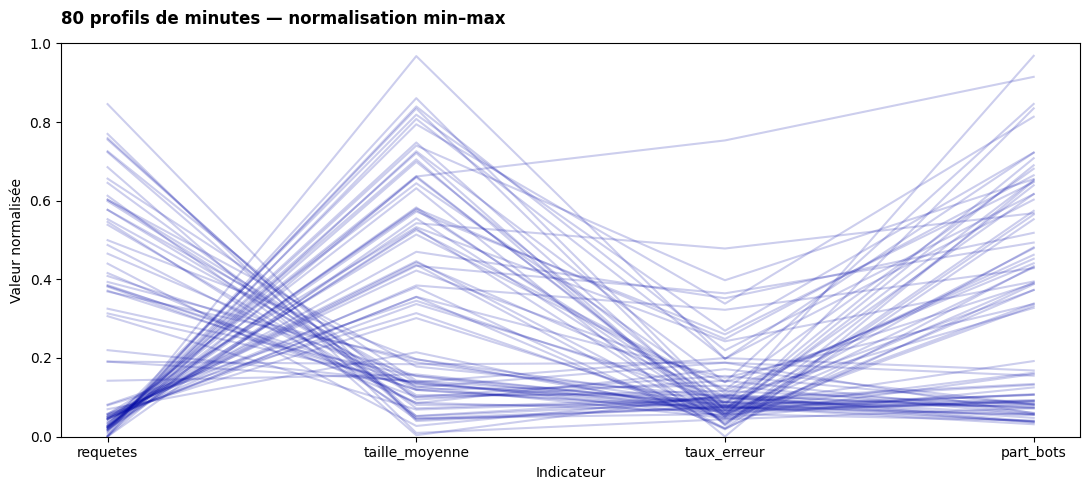

In [26]:
ID_GRAPHIQUE = '04_06'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
for _,r in ech.iterrows():ax.plot(range(4),r,alpha=.2,color=palette[0])
ax.set_xticks(range(4),variables);ax.set_ylim(0,1)
terminer(ax,'80 profils de minutes — normalisation min–max','Indicateur','Valeur normalisée')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn</div></b>

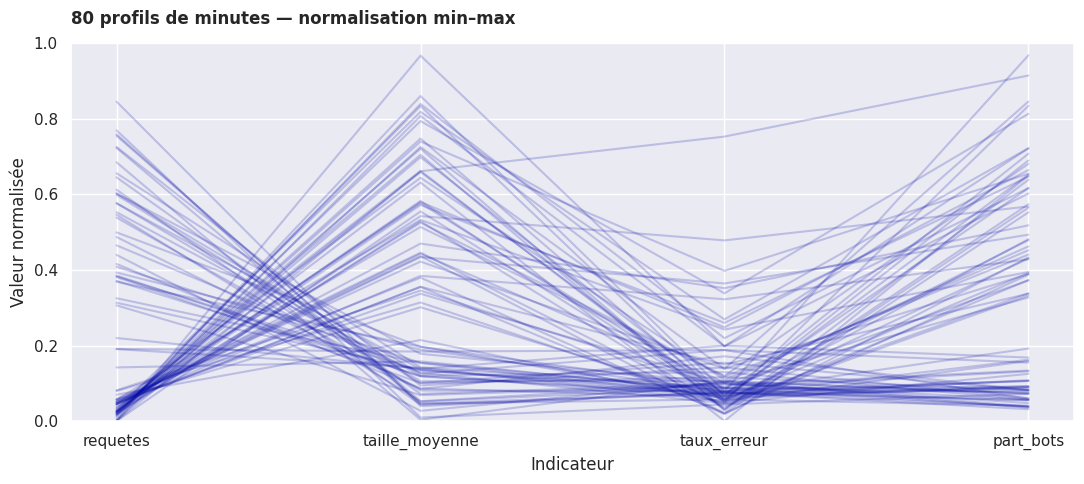

In [27]:
ID_GRAPHIQUE = '04_06'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
long=ech.reset_index(names='profil').melt(id_vars='profil',var_name='variable',value_name='normalise')
sns.lineplot(data=long,x='variable',y='normalise',units='profil',estimator=None,alpha=.2,color=palette[0],sort=False,ax=ax);ax.set_ylim(0,1)
terminer(ax,'80 profils de minutes — normalisation min–max','Indicateur','Valeur normalisée')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [28]:
ID_GRAPHIQUE = '04_06'
BIBLIOTHEQUE = 'plotly'
fig=go.Figure(go.Parcoords(dimensions=[dict(label=c,values=ech[c],range=[0,1]) for c in variables],line=dict(color=ech.requetes,colorscale='Blues',showscale=True,colorbar_title='Volume normalisé')))
montrer_plotly(fig,'80 profils de minutes — normalisation min–max')

**À lire dans les trois variantes :** Comparer 80 profils de minutes, échantillonnés avec une graine fixe. Variables : 4Q. Min–max calculé sur toutes les minutes complètes ; les valeurs normalisées ne conservent pas les unités.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Synthèse et exercices</div></b>

1. Reformuler la question métier de chacun des six graphiques.
2. Modifier un filtre ou une période et expliquer son effet sur le dénominateur.
3. Choisir une variante pour un rapport imprimé et une pour un tableau de bord interactif.
4. Vérifier l’unité, l’effectif, les valeurs manquantes et le sens des encodages.

**Limites :** Le fichier couvre seulement le 22 janvier 2019, de 00:26 à 07:36 UTC environ. Les premières et dernières minutes sont incomplètes. Les mesures portent sur des requêtes, pas sur des personnes. Les adresses IP et URL brutes ne sont pas chargées.